# OLS Regression — Week 2
**Aayan Mulani │ Decimal Point Analytics Preparation**

OLS (Ordinary Least Squares) regression finds the linear relationship between two variables
by minimising the sum of squared errors. In finance, regression is used to model how one
asset moves relative to another — for example, how Nifty returns respond to Sensex returns.
This notebook builds a simple OLS model using the two major Indian indices.

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Download Nifty 50 (Y) and Sensex (X) — 5 years of daily data
# .squeeze() converts single-column DataFrame → Series (required for newer yfinance)
nifty  = yf.download('^NSEI',  start='2020-01-01', end='2025-01-01')['Close'].squeeze()
sensex = yf.download('^BSESN', start='2020-01-01', end='2025-01-01')['Close'].squeeze()

# Combine into one DataFrame and compute daily returns
df = pd.DataFrame({'Nifty': nifty, 'Sensex': sensex}).dropna()
df['Nifty_Ret']  = df['Nifty'].pct_change()
df['Sensex_Ret'] = df['Sensex'].pct_change()
df.dropna(inplace=True)

print(df.shape)
print(df.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(1233, 4)
                   Nifty        Sensex  Nifty_Ret  Sensex_Ret
Date                                                         
2020-01-03  12226.650391  41464.609375  -0.004523   -0.003892
2020-01-06  11993.049805  40676.628906  -0.019106   -0.019004
2020-01-07  12052.950195  40869.468750   0.004995    0.004741
2020-01-08  12025.349609  40817.738281  -0.002290   -0.001266
2020-01-09  12215.900391  41452.351562   0.015846    0.015547


## 1. Scatter Plot — Visualising the Relationship

Before running any regression, always plot X vs Y. If the scatter plot shows no pattern,
regression won't help. If it shows a clear linear cloud, OLS is appropriate.

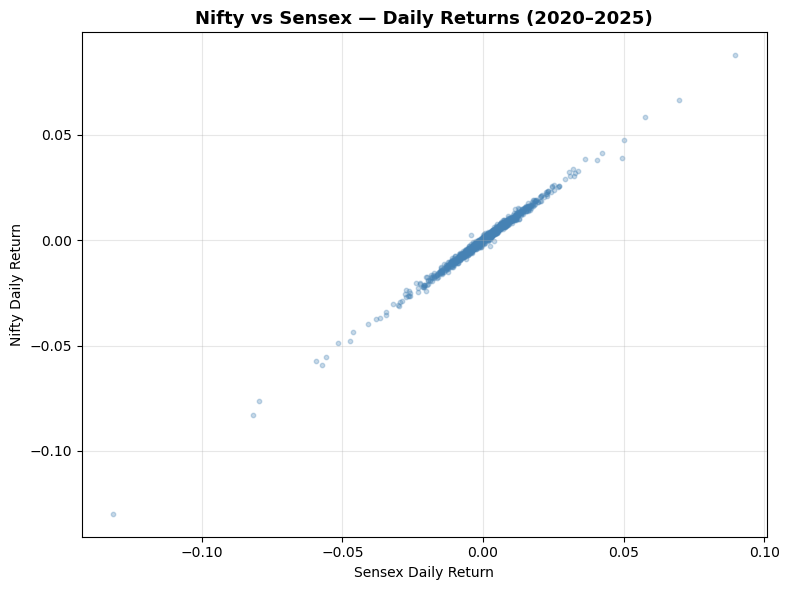

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(df['Sensex_Ret'], df['Nifty_Ret'], alpha=0.3, color='steelblue', s=10)
plt.xlabel('Sensex Daily Return')
plt.ylabel('Nifty Daily Return')
plt.title('Nifty vs Sensex — Daily Returns (2020–2025)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. OLS Regression — Nifty Returns ~ Sensex Returns

Model: Nifty_Return = b0 (intercept) + b1 × Sensex_Return + error

statsmodels requires us to manually add the intercept column using sm.add_constant().
Without it, the model forces the regression line through the origin (b0 = 0),
which is usually incorrect.

In [6]:
# Prepare X and Y
X = sm.add_constant(df['Sensex_Ret'])  # adds a column of 1s for the intercept
Y = df['Nifty_Ret']

# Fit the OLS model
model = sm.OLS(Y, X).fit()

# Print the full regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Nifty_Ret   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 1.753e+05
Date:                Tue, 26 May 2026   Prob (F-statistic):               0.00
Time:                        10:51:25   Log-Likelihood:                 6759.8
No. Observations:                1233   AIC:                        -1.352e+04
Df Residuals:                    1231   BIC:                        -1.351e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.876e-05   2.87e-05      1.001      0.3

## Interpretation of OLS Results

**R² = 0.993:** The Sensex explains 99.3% of Nifty's daily return variation.
This is exceptionally high and expected — both indices track India's large-cap
equity universe and share most of the same underlying stocks.

**Slope (b1) = 0.9823, p = 0.000:** For every 1% move in the Sensex, the Nifty
moves approximately 0.9823% in the same direction. This coefficient is highly
statistically significant (p essentially zero). The Nifty is slightly less
volatile than the Sensex on a daily basis.

**Intercept (b0) = 0.0000288, p = 0.317:** Not statistically significant.
Nifty has no independent daily drift when Sensex is flat. We cannot reject the
null hypothesis that b0 = 0.

**Durbin-Watson = 2.034:** Close to 2.0 — no autocorrelation in residuals. The
errors are not serially correlated, which satisfies one of OLS's key assumptions.

**Jarque-Bera p = 0.00, Kurtosis = 11.98:** Residuals are not normally distributed
— fat tails remain even after accounting for Sensex. This is typical of financial
return data and a known limitation of standard OLS in markets.

## 3. Regression Line — Best Fit Visualised

Plotting the OLS regression line over the scatter confirms visually what the
summary table told us numerically — a near-perfect linear fit between Sensex
and Nifty daily returns.

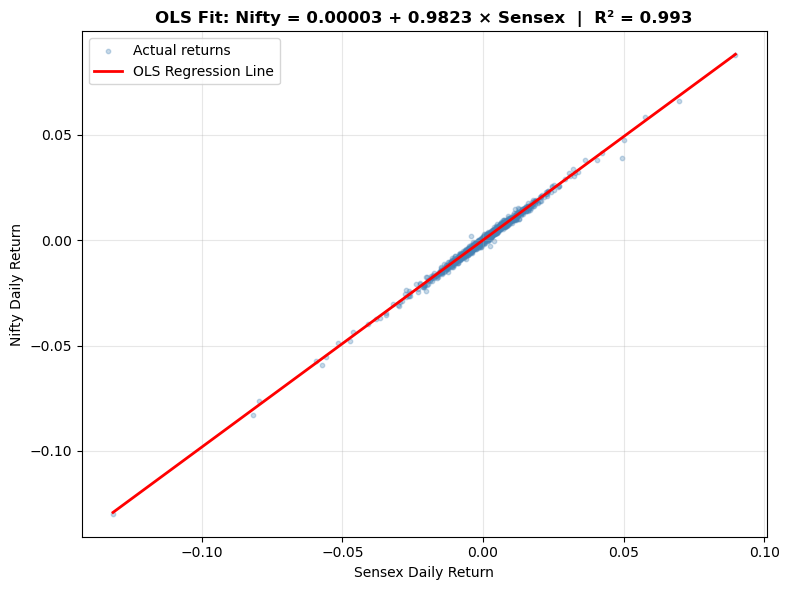

In [7]:
# Sort values so the regression line draws cleanly
plot_df = df[['Sensex_Ret', 'Nifty_Ret']].copy()
plot_df['Fitted'] = model.fittedvalues
plot_df = plot_df.sort_values('Sensex_Ret')

plt.figure(figsize=(8, 6))
plt.scatter(df['Sensex_Ret'], df['Nifty_Ret'],
            alpha=0.3, color='steelblue', s=10, label='Actual returns')
plt.plot(plot_df['Sensex_Ret'], plot_df['Fitted'],
         color='red', linewidth=2, label='OLS Regression Line')

b0 = model.params['const']
b1 = model.params['Sensex_Ret']
plt.title(f'OLS Fit: Nifty = {b0:.5f} + {b1:.4f} × Sensex  |  R² = 0.993',
          fontsize=12, fontweight='bold')
plt.xlabel('Sensex Daily Return')
plt.ylabel('Nifty Daily Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()